# Building the Knowledge Model

In this notebook, we begin by loading the clean dataset obtained from the preprocessing stage. Next, we go through various steps to generate data that describe normal network behavior. Specifically, this phase involves detecting and removing features that are highly correlated with the Key Performance Indicator (KPI), identifying performance outliers and anomalies, and building an XGBoost regression model that characterizes normal network behavior. 

In this case, we utilize various functions from the ``scikit-learn`` library, a Python library that supports many supervised and unsupervised machine learning techniques. Additionally, we employ the ``matplotlib`` library, which provides several visualization tools to display our results. We also need the ``xgboost`` library to build the regression model that describes normal network behavior.

## Import Libraries

In [3]:
import pandas as pd
import numpy as np

# Ploting libraries
import matplotlib.pyplot as plt

# Scikit-learn libraries
from sklearn import mixture

import warnings
warnings.filterwarnings('ignore')

## Loading the Clean Dataset

This subphase loads the clean dataset generated by the preprocessing stage.

In [5]:
print('-----------------------------------------')
print('LOADING DATASET A FILE DOWNLOAD DATASET')
data_file = 'data/Op1_CapDL_NoSteps.csv'
data = pd.read_csv(data_file, sep=",", decimal='.', low_memory = False)
data = data.drop(columns=['Unnamed: 0'])
print('Data Size:(%d, %d)'%(data.shape[0], data.shape[1]))
print('-----------------------------------------')
target_kpi = 'transfer.datarate'
data.describe()

-----------------------------------------
LOADING DATASET A FILE DOWNLOAD DATASET
Data Size:(1001, 134)
-----------------------------------------


,resets.sent.a2b,ack.pkts.sent.a2b,pure.acks.sent.b2a,sack.pkts.sent.b2a,dsack.pkts.sent.a2b,actual.data.bytes.b2a,rexmt.data.bytes.a2b,rexmt.data.bytes.b2a,outoforder.pkts.b2a,pushed.data.pkts.b2a,...,abs.instanttp.75.,abs.instanttp.max,abs.burst.sum,abs.rtoevents.sum,abs.theoricalmaxtp.25.,abs.theoricalmaxtp.50.,abs.theoricalmaxtp.avg,abs.theoricalmaxtp.75.,abs.theoricalmaxtp.max,transfer.datarate
count,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1.001000e+03,1001.000000,1.001000e+03,1001.000000,1001.000000,...,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1.001000e+03,1001.000000,1.001000e+03,1.001000e+03
mean,128.041958,23504.771229,19.445554,0.000999,645.926074,3.633937e+08,2.017982,2.334520e+06,1028.684316,12308.755245,...,491.758768,741.466738,63.993007,236.949051,441.625503,561.372499,6.736559e+09,710.863775,3.329800e+13,3.934347e+05
std,95.049736,11232.441681,35.021355,0.031607,3311.848603,1.816432e+08,46.315242,7.746871e+06,4453.186531,4153.813206,...,226.283063,297.944038,159.287303,1485.634821,233.282453,280.155248,1.424162e+10,348.507113,2.990747e+13,1.984722e+05
min,0.000000,1299.000000,5.000000,0.000000,0.000000,2.530626e+06,0.000000,0.000000e+00,0.000000,229.000000,...,3.357520,8.971200,0.000000,0.000000,1.577791,2.184153,2.317959e+00,2.650657,9.010940e+00,2.408967e+03
25%,62.000000,18357.000000,6.000000,0.000000,0.000000,2.339057e+08,0.000000,0.000000e+00,32.000000,9796.000000,...,332.409600,541.194240,0.000000,0.000000,270.515163,354.645581,9.986515e+02,460.914598,6.019258e+04,2.530839e+05
50%,117.000000,23260.000000,9.000000,0.000000,23.000000,3.482581e+08,0.000000,1.081380e+05,75.000000,12746.000000,...,479.229920,767.104400,13.000000,3.000000,424.008163,541.358703,2.691650e+09,678.650452,3.004338e+13,3.813481e+05
75%,176.000000,27219.000000,17.000000,0.000000,185.000000,4.789645e+08,0.000000,1.393763e+06,322.000000,14987.000000,...,634.784640,935.788080,53.000000,26.000000,597.308615,743.697358,7.241105e+09,934.029041,5.818665e+13,5.196789e+05
max,748.000000,105106.000000,521.000000,1.000000,31047.000000,1.163245e+09,1397.000000,8.789408e+07,41515.000000,26067.000000,...,1443.523040,1818.965520,1956.000000,15336.000000,1539.051243,2156.812000,1.970290e+11,2955.655695,1.836066e+14,1.275028e+06


## Detection and Removal of Features Correlated with the KPI

In [7]:
# Compute the matrix of correlation factors and extract the vector related to the target KPI 
corr_matrix = 1 - data.corr(method='pearson').abs()
corr_vector = corr_matrix[target_kpi].to_numpy().reshape(-1,1)

### Gaussian Mixture

In [9]:
eval_window = 40
max_num_clusters = np.min([eval_window + 1, len(corr_vector)])

iterations = 50
bic_ite    = np.zeros((iterations, max_num_clusters - 1))
aic_ite    = np.zeros((iterations, max_num_clusters - 1))
rand_stt   = np.random.randint(2**16, size=(iterations, max_num_clusters - 1)) 

for ii in range(iterations):
    for jj in range(1, max_num_clusters):
        gmm = mixture.GaussianMixture(n_components = jj,
                                      random_state = rand_stt[ii,jj-1])
        gmm.fit(corr_vector)
        bic_ite[ii,jj-1] = gmm.bic(corr_vector)
        aic_ite[ii,jj-1] = gmm.aic(corr_vector)
        
num_opt_clusters_bic = np.argmin(np.mean(bic_ite, axis=0)) + 1
minbic = np.min(np.mean(bic_ite, axis=0))
maxbic = np.max(np.mean(bic_ite, axis=0))
num_opt_clusters_aic = np.argmin(np.mean(aic_ite, axis=0)) + 1
minaic = np.min(np.mean(aic_ite, axis=0))
maxaic = np.max(np.mean(aic_ite, axis=0))

lowest_bic  = np.infty
lowest_aic  = np.infty
bic         = []
aic         = []
for ii in range(iterations):
    gmm_bic = mixture.GaussianMixture(num_opt_clusters_bic,
                                      random_state = rand_stt[ii,num_opt_clusters_bic-1])
    gmm_aic = mixture.GaussianMixture(num_opt_clusters_aic,
                                      random_state = rand_stt[ii,num_opt_clusters_aic-1])
    gmm_bic.fit(corr_vector)
    gmm_aic.fit(corr_vector)
    bic.append(gmm_bic.bic(corr_vector))
    aic.append(gmm_aic.bic(corr_vector))
    if bic[-1] < lowest_bic:
        lowest_bic = bic[-1]
        best_gmmb = gmm_bic
    if aic[-1] < lowest_aic:
        lowest_aic = aic[-1]
        best_gmma = gmm_aic
    clusters_bic = best_gmmb.predict(corr_vector)
    clusters_aic = best_gmma.predict(corr_vector)
    centroids_bic = best_gmmb.means_
    centroids_aic = best_gmma.means_
    
columns_to_remove_bic = data.columns[(clusters_bic == np.argmin(centroids_bic))]
columns_to_remove_aic = data.columns[(clusters_aic == np.argmin(centroids_aic))]

### Visualization tools for Gaussian Mixture Clustering

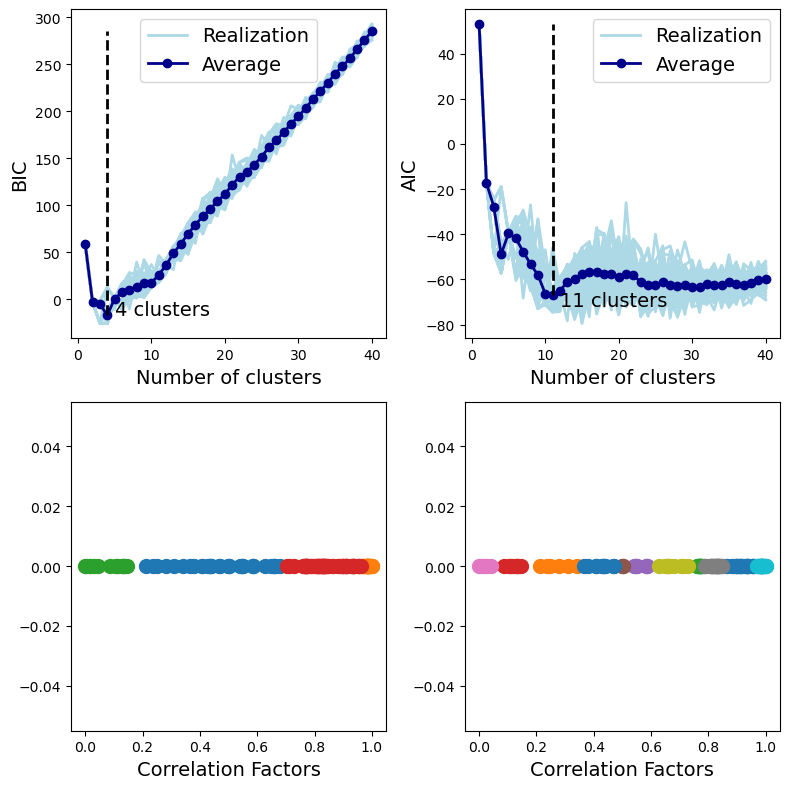

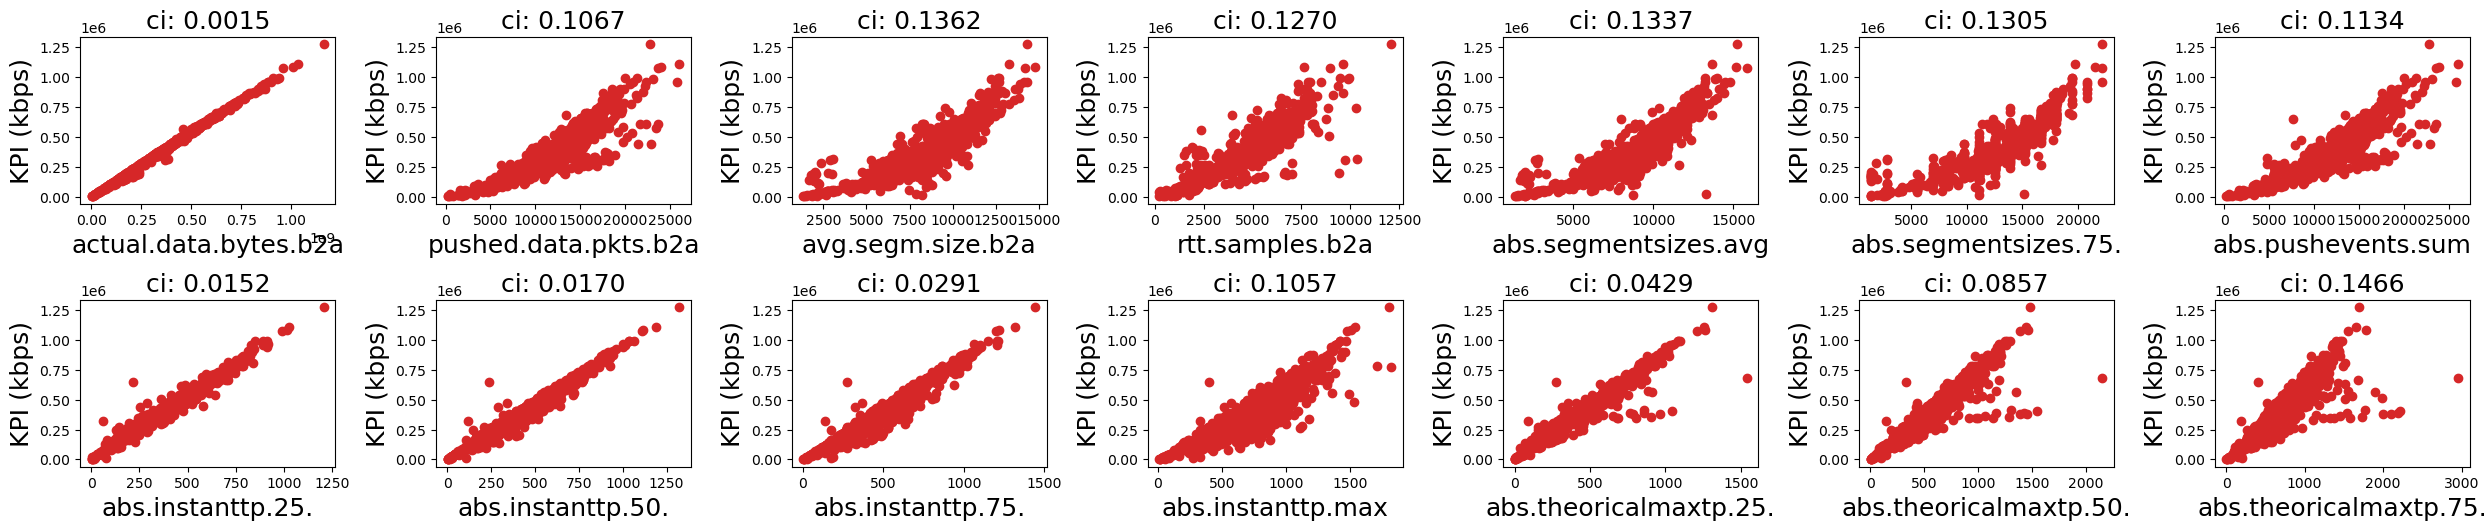

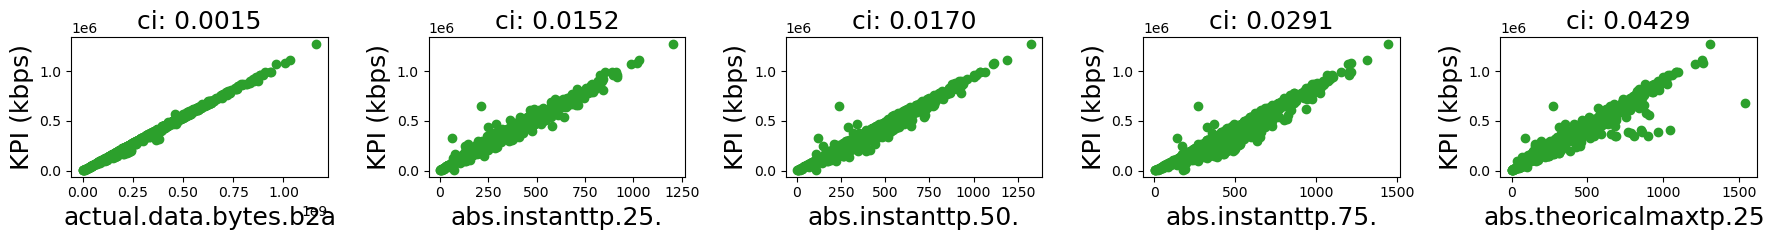

In [11]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(2,2,1)
for ii in range(iterations):
    if (ii ==0):
        plt.plot(np.arange(1, max_num_clusters), bic_ite[ii,:], lw=2, c='lightblue', label='Realization')
    else:
        plt.plot(np.arange(1, max_num_clusters), bic_ite[ii,:], lw=2, c='lightblue')
plt.plot(np.arange(1, max_num_clusters), np.mean(bic_ite, axis=0), '-o',lw=2, c='darkblue', label='Average')
plt.plot([num_opt_clusters_bic, num_opt_clusters_bic], [minbic, maxbic],'k--', lw=2)
plt.xlabel('Number of clusters', fontsize=14)
plt.ylabel('BIC', fontsize=14)
plt.text(num_opt_clusters_bic + 1, np.mean(bic_ite, axis=0)[num_opt_clusters_bic-1], str(num_opt_clusters_bic) + ' clusters', fontsize=14)
plt.legend(fontsize=14)

ax = fig.add_subplot(2,2,2)
for ii in range(iterations):
    if (ii ==0):
        plt.plot(np.arange(1, max_num_clusters), aic_ite[ii,:], lw=2, c='lightblue', label='Realization')
    else:
        plt.plot(np.arange(1, max_num_clusters), aic_ite[ii,:], lw=2, c='lightblue')
plt.plot(np.arange(1, max_num_clusters), np.mean(aic_ite, axis=0), '-o',lw=2, c='darkblue', label='Average')
plt.plot([num_opt_clusters_aic, num_opt_clusters_aic], [minaic, maxaic],'k--', lw=2)
plt.xlabel('Number of clusters', fontsize=14)
plt.ylabel('AIC', fontsize=14)
plt.text(num_opt_clusters_aic + 1, np.mean(aic_ite, axis=0)[num_opt_clusters_aic-1]-5, str(num_opt_clusters_aic) + ' clusters', fontsize=14)
plt.legend(fontsize=14)

ax  = fig.add_subplot(2,2,3)
for i in range(len(np.unique(clusters_bic))):
    plt.scatter(corr_vector[clusters_bic == i], np.zeros(len(corr_vector[clusters_bic == i])), s=100)
plt.xlabel('Correlation Factors', fontsize=14)
    
ax  = fig.add_subplot(2,2,4)
for i in range(len(np.unique(clusters_aic))):
    plt.scatter(corr_vector[clusters_aic == i], np.zeros(len(corr_vector[clusters_aic == i])), s=100)
plt.xlabel('Correlation Factors', fontsize=14)
    
fig.tight_layout()
plt.show()


ncols = 7
nrows = ((len(columns_to_remove_bic) - 1) // ncols) + 1
fig = plt.figure(figsize=(25,2.50*nrows), tight_layout=True)
for ii in range(len(columns_to_remove_bic)-1):
    ax = fig.add_subplot(nrows,ncols,ii+1)
    plt.plot(data[columns_to_remove_bic[ii]], data[target_kpi],'o', color='tab:red')
    plt.xlabel(columns_to_remove_bic[ii], fontsize=18)
    plt.ylabel('KPI (kbps)', fontsize=18)
    plt.title('ci: %.4f'%(corr_matrix[columns_to_remove_bic[ii]][-1]), fontsize=18)
fig.tight_layout()
plt.show()

ncols = 7
nrows = ((len(columns_to_remove_aic) - 1) // ncols) + 1
fig = plt.figure(figsize=(25,2.50*nrows), tight_layout=True)
for ii in range(len(columns_to_remove_aic)-1):
    ax = fig.add_subplot(nrows,ncols,ii+1)
    plt.plot(data[columns_to_remove_aic[ii]], data[target_kpi],'o', color='tab:green')
    plt.xlabel(columns_to_remove_aic[ii], fontsize=18)
    plt.ylabel('KPI (kbps)', fontsize=18)
    plt.title('ci: %.4f'%(corr_matrix[columns_to_remove_aic[ii]][-1]), fontsize=18)
fig.tight_layout()
plt.show()